In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score

In [20]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))

In [21]:
old_data_dir = '/media/ssd1/huong/PCR-huong/data'
new_data_dir = os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

In [22]:

cycle_range_dict = {'LuNER':{'other': np.arange(35,46),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(30,41)},
                    'Thermo': np.arange(30,41)}
                    
fn_range = np.arange(-.9, 0.9, 0.05)

In [29]:
curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

join_df['test_kit'] = join_df.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
join_df['test_kit'] = np.where(join_df.test_kit == 3, 'LuNER', 'Thermo')

test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental', 'Img_wo_range_test_pred_df.csv'))
print(test_pred.shape)
test_pred = (test_pred.merge(join_df.loc[join_df.cycle_no == 1,['curve_idx','igi_call']],
                             on='curve_idx'))
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
print(test_pred.shape)

retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental', 'Img_wo_range_retest_pred_df.csv'))
print(retest_pred.shape)
retest_pred = (retest_pred
             .merge(join_df
                    .loc[(join_df.cycle_no == 1) &
                         (~join_df.target.isin(['MS2','RnaseP'])) &
                         (join_df.final_patient_result != 'ReSample') &
                         (~join_df.final_patient_result.isna()),
                         ['curve_idx','igi_call']],
                    on='curve_idx'))
retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_pred.shape)


(6175, 3)
(6175, 5)
(4084, 3)
(2749, 5)


In [5]:
# known_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_known_val_test_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_karlen_val_test_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_chip60_val_test_pred_df.csv'))

join_df = pd.read_pickle(os.path.join(new_data_dir, 'new_join_df_1.pkl'))
thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
join_df['test_kit'] = 'LuNER'
join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


In [47]:
test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
print(test_pred.shape)
test_pred = (test_pred
             .merge(groundtruth_df[['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx')
             )
print(test_pred.shape)
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_retest_pred_df.csv'))
print(retest_pred.shape)
retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_pred = (retest_pred
               .merge(retest_groundtruth.loc[(retest_groundtruth.final_patient_result != 'ReSample') &
                          (~retest_groundtruth.final_patient_result.isna()) &
                          (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
                          ['curve_idx','groundtruth_target','igi_call']])
               .rename(columns={'groundtruth_target':'groundtruth_label'}))
retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_pred.shape)

(6175, 4)
(6175, 7)
(4084, 4)
(2749, 7)


In [94]:
test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_Seq_Gene_Image_Model_large_val_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
print(test_pred[test_pred.split == 'test'].shape)
test_pred = (test_pred[test_pred.split == 'test']
             .merge(groundtruth_df.loc[groundtruth_df.cycle_no == 1,['curve_idx','sample_id','igi_call','groundtruth']].drop_duplicates(),
                    on='curve_idx')
             )
print(test_pred.shape)
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

retest_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_Seq_Gene_Image_Model_large_val_test_pred_df_retest.csv'))
print(retest_pred.shape)
retest_groundtruth = pd.read_csv(os.path.join(new_data_dir, 'new_retest_df_target_data_1.csv'))
retest_pred = (retest_pred
               .merge(retest_groundtruth.loc[(retest_groundtruth.final_patient_result != 'ReSample') &
                          (~retest_groundtruth.final_patient_result.isna()) &
                          (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
                          ['curve_idx','groundtruth_target','igi_call']])
               .rename(columns={'groundtruth_target':'groundtruth_label'}))
retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_pred.shape)

(23730, 5)
(23680, 8)
(26222, 5)
(17384, 8)


### vary model threshold

In [95]:
model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    test_pred['pred'] = 1*(test_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
    

In [96]:
best_acc_threshold_idx = model_dict_df.acc.idxmax()
best_acc_threshold = model_dict_df.loc[best_acc_threshold_idx, 'thres']
print('Best Accuracy on Test:', model_dict_df.loc[best_acc_threshold_idx, 'acc'])
print('Best Accuracy Threshold on Test:', best_acc_threshold)

Best Accuracy on Test: 0.9970861486486486
Best Accuracy Threshold on Test: 0.28


In [97]:
model_test_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.outputs)
print('Model AUC on test set:', model_test_auc)
test_pred['pred'] = 1*(test_pred.outputs >= best_acc_threshold)
calc_metrics(test_pred.groundtruth_label, test_pred.pred)

Model AUC on test set: 0.9991938723008161


,acc,f1,tn,fp,fn,tp
0,0.997086,0.99839,2223,26,43,21388


In [98]:
igi_test_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.encoded_igi_call)
print('IGI AUC on test set:', igi_test_auc)
calc_metrics(test_pred.groundtruth_label, test_pred.encoded_igi_call)

IGI AUC on test set: 0.9957401107702532


,acc,f1,tn,fp,fn,tp
0,0.99337,0.996324,2246,3,154,21277


In [99]:
model_retest_auc = roc_auc_score(retest_pred.groundtruth_label, retest_pred.outputs)
print('Model AUC on retest:', model_retest_auc)
retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)
calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)

Model AUC on retest: 0.7493007752250346


,acc,f1,tn,fp,fn,tp
0,0.901979,0.487056,14871,803,901,809


In [100]:
igi_retest_auc = roc_auc_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
print('IGI AUC on retest:', igi_retest_auc)
calc_metrics(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)

IGI AUC on retest: 0.7169883899063297


,acc,f1,tn,fp,fn,tp
0,0.879544,0.456668,14410,1264,830,880


In [54]:
retest_model_dict = {'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    retest_pred['pred'] = 1*(retest_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
    
    retest_model_dict['fnr'].append(fn/(fn+tp))
    retest_model_dict['fpr'].append(fp/(fp+tn))
    retest_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
retest_model_dict_df = pd.DataFrame(retest_model_dict)
    

### vary IGI thresholds
#### test set

##### Move individual pcr plate

In [55]:
full_test_pred = (test_pred
                  .merge(join_df[['curve_idx','target','threshold','pcr_plate','test_kit','thres_ct','cycle_no','drn']].drop_duplicates(),
                         on = 'curve_idx'))
full_test_pred['encoded_igi_call'] = 1*(full_test_pred.igi_call == 'Positive')
print(full_test_pred.shape)

(270020, 17)


In [56]:
thres_ct_df = full_test_pred.loc[full_test_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
thres_ct_df['cycle_no'] = thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

new_thres_df = (full_test_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(thres_ct_df, on=['curve_idx','cycle_no']))
new_thres_df['igi_threshold'] = new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_test_pred = (full_test_pred
                  .merge(new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )
full_test_pred.loc[full_test_pred.igi_threshold.isna(),'igi_threshold'] = full_test_pred.loc[full_test_pred.igi_threshold.isna(),'threshold']
print(full_test_pred.shape)
full_test_pred.head(5)

(270020, 18)


,curve_idx,outputs,igi_fp,igi_fn,sample_id,igi_call,groundtruth,encoded_igi_call,groundtruth_label,pred,target,threshold,pcr_plate,test_kit,thres_ct,cycle_no,drn,igi_threshold
0,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,1,178.980698,10249.504305
1,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,2,139.666701,10249.504305
2,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,3,107.274579,10249.504305
3,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,4,80.349253,10249.504305
4,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,5,117.570412,10249.504305


In [57]:
# get best threshold for each plate
plate_target_pair = full_test_pred[['pcr_plate','target','test_kit']].drop_duplicates()
threshold_dict = {'pcr_plate':[],
                  'target':[],
                  'igi_fp':[],
                  'igi_fn':[],
                  'best_fp':[],
                  'best_fn':[],
                  'best_fp_pos_frac':[],
                  'best_fn_pos_frac':[],
                  'best_fp_perc':[],
                  'best_fp_cycle':[],
                  'best_fn_perc':[],
                  'best_fn_cycle':[],
                  'worst_fp':[],
                  'worst_fn':[],
                  'worst_fn_pos_frac':[],
                  'worst_fp_pos_frac':[],
                  'worst_fp_perc':[],
                  'worst_fp_cycle':[],
                  'worst_fn_perc':[],
                  'worst_fn_cycle':[],
                  }

for plate in plate_target_pair.pcr_plate.unique():
    for target in plate_target_pair[plate_target_pair.pcr_plate == plate].target:
        
        temp_thresholds = {'perc':[], 'cycle':[], 'pos_frac':[], 'fnr':[],  'fpr':[]}
        df = full_test_pred[(full_test_pred.target == target) & (full_test_pred.pcr_plate == plate)]
        
        for perc in fn_range:
            df.loc[:,'new_threshold'] = df['igi_threshold'] * (1 + perc)
            df.loc[:,'if_pass'] = df.drn >= df.new_threshold
            df.loc[:,'new_ct'] = np.Inf
            pass_curve_idx = df[df.if_pass].curve_idx.unique()
            df.loc[df.curve_idx.isin(pass_curve_idx), 'new_ct'] = df[df.curve_idx.isin(pass_curve_idx)].groupby(['curve_idx']).cycle_no.transform('min')
    
            df.loc[:,'new_encoded_igi_call'] = 0
            for cycle in range(10):
                df.loc[(df.test_kit == 'Thermo') & (df.new_ct <= cycle_range_dict['Thermo'][cycle]), 'new_encoded_igi_call'] = 1
                # RnaseP
                df.loc[(df.target == 'RnaseP') & (df.new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle]), 'new_encoded_igi_call'] = 1
                # other
                df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP') & (df.new_ct <= cycle_range_dict['LuNER']['other'][cycle]), 'new_encoded_igi_call'] = 1
                
                tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.new_encoded_igi_call, labels = np.array([0,1])).ravel()

                temp_thresholds['perc'].append(perc)
                temp_thresholds['cycle'].append(cycle)
                temp_thresholds['pos_frac'].append((fp+tp)/(fp+tp+fn+tn))
                
                if (fn+tp) == 0:
                    temp_thresholds['fnr'].append(0)
                else:
                    temp_thresholds['fnr'].append(fn/(fn+tp))
                    
                if (fp + tn) == 0:
                    temp_thresholds['fpr'].append(0)
                else:
                	temp_thresholds['fpr'].append(fp/(fp+tn))
        
        igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call, labels = np.array([0,1])).ravel()
        threshold_dict['pcr_plate'].append(plate)
        threshold_dict['target'].append(target)
        if (igi_fp + igi_tn) == 0:
            threshold_dict['igi_fp'].append(0)
        else:
            threshold_dict['igi_fp'].append(igi_fp/(igi_fp + igi_tn))
            
        if (igi_tp + igi_fn) == 0:
            threshold_dict['igi_fn'].append(0)
        else:
            threshold_dict['igi_fn'].append(igi_fn/(igi_tp + igi_fn))
        
        threshold_dict['best_fp'].append(min(temp_thresholds['fpr']))
        best_fp_idx = np.array(temp_thresholds['fpr']).argmin()
        threshold_dict['best_fp_pos_frac'].append(temp_thresholds['pos_frac'][best_fp_idx])
        threshold_dict['best_fp_perc'].append(temp_thresholds['perc'][best_fp_idx])
        threshold_dict['best_fp_cycle'].append(temp_thresholds['cycle'][best_fp_idx])
        
        threshold_dict['best_fn'].append(min(temp_thresholds['fnr']))
        best_fn_idx = np.array(temp_thresholds['fnr']).argmin()
        threshold_dict['best_fn_pos_frac'].append(temp_thresholds['pos_frac'][best_fn_idx])
        threshold_dict['best_fn_perc'].append(temp_thresholds['perc'][best_fn_idx])
        threshold_dict['best_fn_cycle'].append(temp_thresholds['cycle'][best_fn_idx])
        
        worst_fp_idx = np.array(temp_thresholds['fpr']).argmax()
        threshold_dict['worst_fp'].append(max(temp_thresholds['fpr']))
        threshold_dict['worst_fp_pos_frac'].append(temp_thresholds['pos_frac'][worst_fp_idx])
        threshold_dict['worst_fp_perc'].append(temp_thresholds['perc'][worst_fp_idx])
        threshold_dict['worst_fp_cycle'].append(temp_thresholds['cycle'][worst_fp_idx])
        
        worst_fn_idx = np.array(temp_thresholds['fnr']).argmax()
        threshold_dict['worst_fn'].append(max(temp_thresholds['fnr']))
        threshold_dict['worst_fn_pos_frac'].append(temp_thresholds['pos_frac'][worst_fn_idx])
        threshold_dict['worst_fn_perc'].append(temp_thresholds['perc'][worst_fn_idx])
        threshold_dict['worst_fn_cycle'].append(temp_thresholds['cycle'][worst_fn_idx])
        
        
            

/tmp/ipykernel_769669/3561505940.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'new_threshold'] = df['igi_threshold'] * (1 + perc)
/tmp/ipykernel_769669/3561505940.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'if_pass'] = df.drn >= df.new_threshold
/tmp/ipykernel_769669/3561505940.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [58]:
threshold_range_df = pd.DataFrame(threshold_dict)
threshold_range_df.head()

,pcr_plate,target,igi_fp,igi_fn,best_fp,best_fn,best_fp_pos_frac,best_fn_pos_frac,best_fp_perc,best_fp_cycle,best_fn_perc,best_fn_cycle,worst_fp,worst_fn,worst_fn_pos_frac,worst_fp_pos_frac,worst_fp_perc,worst_fp_cycle,worst_fn_perc,worst_fn_cycle
0,AC00GY79,RnaseP,0.0,0.019231,0.0,0.019231,0.910714,0.928571,-0.70,0,-0.9,0,0.25,0.038462,0.892857,0.928571,-0.9,0,0.65,0
1,AC00GY79,N gene,0.0,0.000000,0.0,0.000000,0.250000,0.250000,-0.90,0,-0.9,0,0.00,0.000000,0.250000,0.250000,-0.9,0,-0.90,0
2,AC00GY79,E gene,0.0,0.000000,0.0,0.000000,0.250000,1.000000,0.65,0,-0.9,0,1.00,0.000000,1.000000,1.000000,-0.9,0,-0.90,0
3,AC00H0SF,RnaseP,0.0,0.047619,0.0,0.000000,0.875000,0.875000,-0.90,0,-0.9,0,0.00,0.047619,0.833333,0.875000,-0.9,0,-0.50,0
4,AC00H0SF,N gene,0.0,0.000000,0.0,0.000000,1.000000,1.000000,-0.90,0,-0.9,0,0.00,0.000000,1.000000,1.000000,-0.9,0,-0.90,0


In [59]:
# apply best and worst threshold to each individual plate
### get each plate's best and worst threshold 
new_full_test_pred = (full_test_pred
 .merge(threshold_range_df[['pcr_plate','target','best_fp_perc','best_fp_cycle','best_fn_perc',
                            'best_fn_cycle','worst_fp_perc','worst_fp_cycle','worst_fn_perc','worst_fn_cycle']],
        on=['pcr_plate','target']))
new_full_test_pred['best_fp_threshold'] = new_full_test_pred.igi_threshold * (1 + new_full_test_pred.best_fp_perc)
new_full_test_pred['best_fn_threshold'] = new_full_test_pred.igi_threshold * (1 + new_full_test_pred.best_fn_perc)
new_full_test_pred['worst_fp_threshold'] = new_full_test_pred.igi_threshold * (1 + new_full_test_pred.worst_fp_perc)
new_full_test_pred['worst_fn_threshold'] = new_full_test_pred.igi_threshold * (1 + new_full_test_pred.worst_fn_perc)

### find ct  
new_full_test_pred['best_fp_if_pass'] = new_full_test_pred.drn >= new_full_test_pred.best_fp_threshold
new_full_test_pred['best_fn_if_pass'] = new_full_test_pred.drn >= new_full_test_pred.best_fn_threshold
new_full_test_pred['worst_fp_if_pass'] = new_full_test_pred.drn >= new_full_test_pred.worst_fp_threshold
new_full_test_pred['worst_fn_if_pass'] = new_full_test_pred.drn >= new_full_test_pred.worst_fn_threshold

best_fp_pass_ids = new_full_test_pred[new_full_test_pred.best_fp_if_pass].curve_idx.unique()
best_fn_pass_ids = new_full_test_pred[new_full_test_pred.best_fn_if_pass].curve_idx.unique()
worst_fp_pass_ids = new_full_test_pred[new_full_test_pred.worst_fp_if_pass].curve_idx.unique()
worst_fn_pass_ids = new_full_test_pred[new_full_test_pred.worst_fn_if_pass].curve_idx.unique()

new_full_test_pred['best_fp_ct'] = np.Inf
new_full_test_pred['best_fn_ct'] = np.Inf
new_full_test_pred['worst_fp_ct'] = np.Inf
new_full_test_pred['worst_fn_ct'] = np.Inf

new_full_test_pred.loc[new_full_test_pred.curve_idx.isin(best_fp_pass_ids),'best_fp_ct'] = (new_full_test_pred[new_full_test_pred.curve_idx.isin(best_fp_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))
new_full_test_pred.loc[new_full_test_pred.curve_idx.isin(best_fn_pass_ids),'best_fn_ct'] = (new_full_test_pred[new_full_test_pred.curve_idx.isin(best_fn_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))
new_full_test_pred.loc[new_full_test_pred.curve_idx.isin(worst_fp_pass_ids),'worst_fp_ct'] = (new_full_test_pred[new_full_test_pred.curve_idx.isin(worst_fp_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))
new_full_test_pred.loc[new_full_test_pred.curve_idx.isin(worst_fn_pass_ids),'worst_fn_ct'] = (new_full_test_pred[new_full_test_pred.curve_idx.isin(worst_fn_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))

### apply IGI rule on ct for each test kit
new_full_test_pred['best_fp_igi_call'] = 0
new_full_test_pred['best_fn_igi_call'] = 0
new_full_test_pred['worst_fp_igi_call'] = 0
new_full_test_pred['worst_fn_igi_call'] = 0

new_full_test_pred['actual_best_fp_cycle'] = new_full_test_pred['best_fp_cycle']
new_full_test_pred['actual_best_fn_cycle'] = new_full_test_pred['best_fn_cycle']
new_full_test_pred['actual_worst_fp_cycle'] = new_full_test_pred['worst_fp_cycle']
new_full_test_pred['actual_worst_fn_cycle'] = new_full_test_pred['worst_fn_cycle']

new_full_test_pred.loc[(new_full_test_pred.test_kit == 'Thermo'),'actual_best_fp_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'Thermo')].best_fp_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'Thermo'),'actual_best_fn_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'Thermo')].best_fn_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'Thermo'),'actual_worst_fp_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'Thermo')].worst_fp_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'Thermo'),'actual_worst_fn_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'Thermo')].worst_fn_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])

new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target == 'RnaseP'),'actual_best_fp_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target == 'RnaseP')].best_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target == 'RnaseP'),'actual_best_fn_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target == 'RnaseP')].best_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target == 'RnaseP'),'actual_worst_fp_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target == 'RnaseP')].worst_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target == 'RnaseP'),'actual_worst_fn_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target == 'RnaseP')].worst_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])

new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target != 'RnaseP'),'actual_best_fp_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target != 'RnaseP')].best_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target != 'RnaseP'),'actual_best_fn_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target != 'RnaseP')].best_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target != 'RnaseP'),'actual_worst_fp_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target != 'RnaseP')].worst_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])
new_full_test_pred.loc[(new_full_test_pred.test_kit == 'LuNER') & (new_full_test_pred.target != 'RnaseP'),'actual_worst_fn_cycle'] = new_full_test_pred[(new_full_test_pred.test_kit == 'LuNER')& (new_full_test_pred.target != 'RnaseP')].worst_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])

new_full_test_pred.loc[(new_full_test_pred.best_fp_ct <= new_full_test_pred.actual_best_fp_cycle),'best_fp_igi_call'] = 1
new_full_test_pred.loc[(new_full_test_pred.best_fn_ct <= new_full_test_pred.actual_best_fn_cycle),'best_fn_igi_call'] = 1
new_full_test_pred.loc[(new_full_test_pred.worst_fp_ct <= new_full_test_pred.actual_worst_fp_cycle),'worst_fp_igi_call'] = 1
new_full_test_pred.loc[(new_full_test_pred.worst_fn_ct <= new_full_test_pred.actual_worst_fn_cycle),'worst_fn_igi_call'] = 1


In [60]:
best_fp_tn, best_fp_fp, best_fp_fn, best_fp_tp = confusion_matrix(new_full_test_pred.groundtruth_label, new_full_test_pred.best_fp_igi_call, labels=np.array([0,1])).ravel()
best_fp_fpr = best_fp_fp/(best_fp_fp+best_fp_tn)
best_fp_fnr = best_fp_fn/(best_fp_fn+best_fp_tp)
best_fpr_pos_frac = (best_fp_fp + best_fp_tp)/(best_fp_fp+best_fp_tp+best_fp_fn+best_fp_tn)
print('Best simulated FPR:', best_fp_fpr)
print('Corresponding Positive fraction that achieve best FPR:', best_fpr_pos_frac)
print('Corresponding FNR:', best_fp_fnr)

Best simulated FPR: 0.026408125577100646
Corresponding Positive fraction that achieve best FPR: 0.8784904821865047
Corresponding FNR: 0.026549218959023648


In [61]:
worst_fp_tn, worst_fp_fp, worst_fp_fn, worst_fp_tp = confusion_matrix(new_full_test_pred.groundtruth_label, new_full_test_pred.worst_fp_igi_call, labels=np.array([0,1])).ravel()
worst_fp_fpr = worst_fp_fp/(worst_fp_fp+worst_fp_tn) 
worst_fp_fnr = worst_fp_fn/(worst_fp_fn+worst_fp_tp) 
worst_fpr_pos_frac = (worst_fp_fp + worst_fp_tp)/(worst_fp_fp+worst_fp_tp+worst_fp_fn+worst_fp_tn)
print('Worst simulated FPR:', worst_fp_fpr)
print('Corresponding Positive fraction that achieve worst FPR:', worst_fpr_pos_frac)
print('Corresponding FNR:', worst_fp_fnr)

Worst simulated FPR: 0.48808864265927976
Corresponding Positive fraction that achieve worst FPR: 0.9281349529664469
Corresponding FNR: 0.02282409598880405


In [27]:
# igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(new_full_test_pred.groundtruth_label, new_full_test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
# igi_fnr = igi_fn/(igi_fn+igi_tp) 
# igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
# igi_fpr = igi_fp/(igi_fp + igi_tn)


In [62]:
best_fn_tn, best_fn_fp, best_fn_fn, best_fn_tp = confusion_matrix(new_full_test_pred.groundtruth_label, new_full_test_pred.best_fn_igi_call, labels=np.array([0,1])).ravel()
best_fn_fnr = best_fn_fn/(best_fn_fn+best_fn_tp)
best_fn_fpr = best_fn_fp/(best_fn_fp+best_fn_tn)
best_fnr_pos_frac = (best_fn_fp + best_fn_tp)/(best_fn_fp+best_fn_tp+best_fn_fn+best_fn_tn)
print('Best simulated FNR:', best_fn_fnr)
print('Corresponding Positive fraction that achieve best FNR:', best_fnr_pos_frac)
print('Corresponding FPR:', best_fn_fpr)

Best simulated FNR: 0.02282409598880405
Corresponding Positive fraction that achieve best FNR: 0.9281349529664469
Corresponding FPR: 0.48808864265927976


In [63]:
worst_fn_tn, worst_fn_fp, worst_fn_fn, worst_fn_tp = confusion_matrix(new_full_test_pred.groundtruth_label, new_full_test_pred.worst_fn_igi_call, labels=np.array([0,1])).ravel()
worst_fn_fnr = worst_fn_fn/(worst_fn_fn+worst_fn_tp)
worst_fn_fpr = worst_fn_fp/(worst_fn_fp+worst_fn_tn)
worst_fnr_pos_frac = (worst_fn_fp + worst_fn_tp)/(worst_fn_fp+worst_fn_tp+worst_fn_fn+worst_fn_tn)
print('Worst simulated FNR:', worst_fn_fnr)
print('Corresponding Positive fraction that achieve worst FNR:', worst_fnr_pos_frac)
print('Corresponding FPR:', worst_fn_fpr)

Worst simulated FNR: 0.0451336722303402
Corresponding Positive fraction that achieve worst FNR: 0.9014147100214799
Corresponding FPR: 0.42179132040627887


#### systematically shift the Fn threshold and Ct

In [64]:
thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_test_pred.copy()
        df['new_threshold'] = full_test_pred.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.new_igi_call, labels=np.array([0,1])).ravel()
        
        thres_df['fpr'].append(fp/(fp+tn))
        thres_df['fnr'].append(fn/(fn+tp))
        thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

### randomly pick pcr plates to have Fn threshold to shift randomly

In [37]:
# random_df = {'tn':[], 'fp':[], 'fn':[], 'tp':[]}
# choices_df = {'iteration':[], 'plate':[], 'target':[], 'perc':[], 'cycle':[]}
# for i in range(50):
#     total_tn, total_fp, total_fn, total_tp = 0,0,0,0
#     np.random.seed(i)
#     for plate in full_test_pred.pcr_plate.unique():
#         plate_df = full_test_pred[full_test_pred.pcr_plate == plate].copy()
#         for target in plate_df.target.unique():
#             perc = np.random.choice(fn_range)
#             cycle = np.random.choice(np.array(range(10)))
#             choices_df['iteration'].append(i)
#             choices_df['plate'].append(plate)
#             choices_df['target'].append(target)
#             choices_df['perc'].append(perc)
            
#             df = plate_df[plate_df.target == target].copy()
#             df['new_threshold'] = df.igi_threshold * (1 + perc)
#             df['if_pass'] = df.drn >= df.new_threshold 
#             passed_ids = df[df.if_pass].curve_idx.unique()
            
#             df['new_ct'] = np.Inf
#             df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
            
#             if df.test_kit.iloc[0] == 'Thermo':
#                 df['new_igi_call'] = 1*(df.new_ct <= cycle_range_dict['Thermo'][cycle])
#                 choices_df['cycle'].append(cycle_range_dict['Thermo'][cycle])
#             else:
#                 if target == 'RnaseP':
#                     df['new_igi_call'] = 1*(df.new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
#                     choices_df['cycle'].append(cycle_range_dict['LuNER']['RnaseP'][cycle])
#                 else:
#                     df['new_igi_call'] = 1*(df.new_ct <= cycle_range_dict['LuNER']['other'][cycle])
#                     choices_df['cycle'].append(cycle_range_dict['LuNER']['other'][cycle])
            
#             tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.new_igi_call, labels=np.array([0,1])).ravel()
            
#             total_tn += tn
#             total_fp += fp
#             total_fn += fn
#             total_tp += tp
            
#     random_df['tn'].append(total_tn)
#     random_df['fn'].append(total_fn)
#     random_df['fp'].append(total_fp)
#     random_df['tp'].append(total_tp)
            
            

In [38]:
# random_500_df = pd.DataFrame(random_df)
# random_500_df['fpr'] = random_500_df.fp/(random_500_df.fp + random_500_df.tn)
# random_500_df['fnr'] = random_500_df.fn/(random_500_df.fn + random_500_df.tp)

# random_500_df['pos_pred'] = (random_500_df.fp + random_500_df.tp)/(random_500_df.fn + random_500_df.fp + random_500_df.tn + random_500_df.tp)
# random_500_df['fpr_type'] = 'simulated'
# random_500_df['fnr_type'] = 'simulated'


In [65]:
final_thres_df = pd.DataFrame(thres_df)
final_thres_df['fpr_type'] = 'simulated'
final_thres_df['fnr_type'] = 'simulated'

final_thres_df = pd.concat([final_thres_df, 
                            pd.DataFrame({'fpr': [best_fp_fpr, best_fn_fpr, worst_fp_fpr, worst_fn_fpr],
                            'fnr': [best_fp_fnr, best_fn_fnr, worst_fp_fnr, worst_fn_fnr],
                            'pos_pred':[best_fpr_pos_frac, best_fnr_pos_frac, worst_fpr_pos_frac, worst_fnr_pos_frac],
                            'fpr_type':['best', 'simulated', 'worst', 'simulated'],
                            'fnr_type':['simulated','best','simulated','worst']
                            }),
                            # random_500_df[['fpr','fnr','pos_pred','fpr_type','fnr_type']]
                            ])
# final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_imgnew_test_final_thres_df.csv')

In [40]:
# final_thres_df = pd.read_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_imgnew_test_final_thres_df.csv')

In [66]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(full_test_pred.groundtruth_label, full_test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
igi_fnr = igi_fn/(igi_fn+igi_tp) 
igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
igi_fpr = igi_fp/(igi_fp + igi_tn)
print('Current IGI FNR:', igi_fnr)
print('Current IGI FPR:', igi_fpr)
print('Current IGI positive fraction:', igi_pos_frac)

Current IGI FNR: 0.04505134907077734
Current IGI FPR: 0.0
Current IGI positive fraction: 0.8591956151396193


In [67]:
true_pos_frac = sum(full_test_pred.groundtruth_label == 1)/full_test_pred.shape[0]
print('True positive fraction:', true_pos_frac)

True positive fraction: 0.8997296496555811


Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on test set')

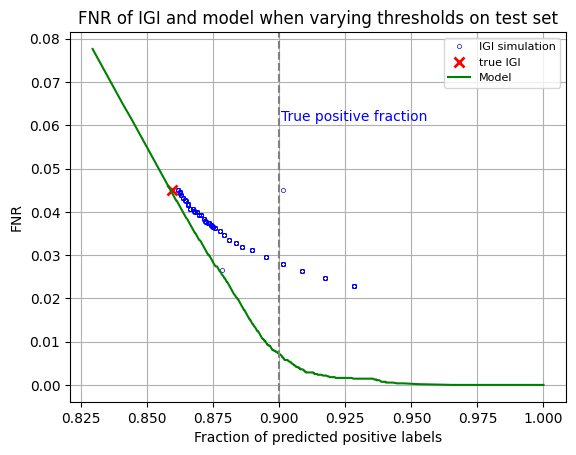

In [68]:

plt.plot(final_thres_df.pos_pred, 
         final_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(model_dict_df.pos_frac, model_dict_df.fnr, color='green', label='Model')
plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac + 0.001, y = 0.061, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on test set')

Text(0.5, 1.0, 'FPR of IGI and model when varying thresholds on test set')

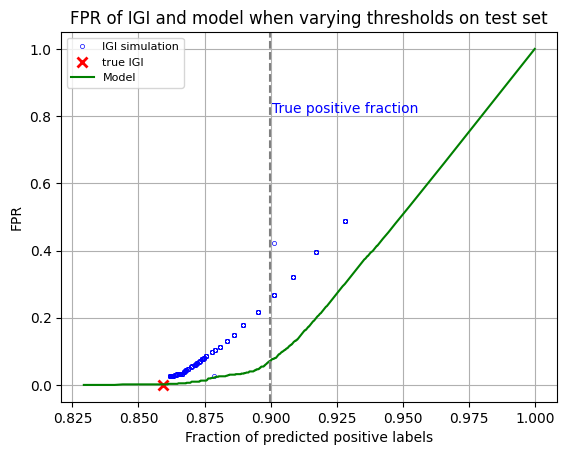

In [69]:

plt.plot(final_thres_df.pos_pred, 
         final_thres_df.fpr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(model_dict_df.pos_frac, model_dict_df.fpr, color='green', label='Model')
plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac + 0.001, y = 0.81, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.025,0.15)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.title('FPR of IGI and model when varying thresholds on test set')

In [103]:
# final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_test_final_thres_df.csv', index=False)

#### retest

In [70]:
full_retest_pred = (retest_pred
                  .merge(join_df[['curve_idx','threshold','target','pcr_plate','test_kit','thres_ct','cycle_no','drn']], #
                         on = 'curve_idx'))
# full_retest_pred['encoded_igi_call'] = 1*(full_retest_pred.igi_call == 'Positive')
print(full_retest_pred.shape)

(118440, 15)


In [71]:
full_retest_pred['pred'] = 1*(full_retest_pred.outputs >= best_acc_threshold)
tn, fp, fn, tp = confusion_matrix(full_retest_pred.groundtruth_label, full_retest_pred.pred, labels=np.array([0,1])).ravel()

true_retest_pos_frac = (tp+fp)/(tp+fp+fn+tn)
print('True retest positive fraction:', true_retest_pos_frac)


True retest positive fraction: 0.07721209050996285


In [72]:
retest_thres_ct_df = full_retest_pred.loc[full_retest_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
retest_thres_ct_df['cycle_no'] = retest_thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

retest_new_thres_df = (full_retest_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(retest_thres_ct_df, on=['curve_idx','cycle_no']))
retest_new_thres_df['igi_threshold'] = retest_new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_retest_pred = (full_retest_pred
                  .merge(retest_new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )


full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'igi_threshold'] = full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'threshold']
print(full_retest_pred.shape)
full_retest_pred.head(5)

(118440, 16)


,curve_idx,outputs,igi_fp,igi_fn,groundtruth_label,igi_call,encoded_igi_call,pred,threshold,target,pcr_plate,test_kit,thres_ct,cycle_no,drn,igi_threshold
0,2554,0.000134,2.097833e-09,0.000069,0.0,Negative,0,0,6644.436,N gene,AC00DAPC,Thermo,Undetermined,1,-916.260639,6644.436
1,2554,0.000134,2.097833e-09,0.000069,0.0,Negative,0,0,6644.436,N gene,AC00DAPC,Thermo,Undetermined,2,-917.620179,6644.436
2,2554,0.000134,2.097833e-09,0.000069,0.0,Negative,0,0,6644.436,N gene,AC00DAPC,Thermo,Undetermined,3,-853.409406,6644.436
3,2554,0.000134,2.097833e-09,0.000069,0.0,Negative,0,0,6644.436,N gene,AC00DAPC,Thermo,Undetermined,4,-822.042383,6644.436
4,2554,0.000134,2.097833e-09,0.000069,0.0,Negative,0,0,6644.436,N gene,AC00DAPC,Thermo,Undetermined,5,-233.940986,6644.436


In [73]:
retest_plate_target_pair = full_retest_pred[['pcr_plate','target','test_kit']].drop_duplicates()


### move threshold for individual plates

In [74]:
retest_threshold_dict = {'pcr_plate':[],
                  'target':[],
                  'igi_fp':[],
                  'igi_fn':[],
                  'best_fp':[],
                  'best_fn':[],
                  'best_fp_pos_frac':[],
                  'best_fn_pos_frac':[],
                  'best_fp_perc':[],
                  'best_fp_cycle':[],
                  'best_fn_perc':[],
                  'best_fn_cycle':[],
                  'worst_fp':[],
                  'worst_fn':[],
                  'worst_fn_pos_frac':[],
                  'worst_fp_pos_frac':[],
                  'worst_fp_perc':[],
                  'worst_fp_cycle':[],
                  'worst_fn_perc':[],
                  'worst_fn_cycle':[],
                  }

for plate in retest_plate_target_pair.pcr_plate.unique():
    for target in retest_plate_target_pair[retest_plate_target_pair.pcr_plate == plate].target:
        
        temp_thresholds = {'perc':[], 'cycle':[], 'pos_frac':[], 'fnr':[],  'fpr':[]}
        df = full_retest_pred[(full_retest_pred.target == target) & (full_retest_pred.pcr_plate == plate)]
        
        for perc in fn_range:
            df.loc[:,'new_threshold'] = df['igi_threshold'] * (1 + perc)
            df.loc[:,'if_pass'] = df.drn >= df.new_threshold
            df.loc[:,'new_ct'] = np.Inf
            pass_curve_idx = df[df.if_pass].curve_idx.unique()
            df.loc[df.curve_idx.isin(pass_curve_idx), 'new_ct'] = df[df.curve_idx.isin(pass_curve_idx)].groupby(['curve_idx']).cycle_no.transform('min')
    
            df.loc[:,'new_encoded_igi_call'] = 0
            for cycle in range(10):
                df.loc[(df.test_kit == 'Thermo') & (df.new_ct <= cycle_range_dict['Thermo'][cycle]), 'new_encoded_igi_call'] = 1
                # RnaseP
                df.loc[(df.target == 'RnaseP') & (df.new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle]), 'new_encoded_igi_call'] = 1
                # other
                df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP') & (df.new_ct <= cycle_range_dict['LuNER']['other'][cycle]), 'new_encoded_igi_call'] = 1
                
                tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.new_encoded_igi_call, labels = np.array([0,1])).ravel()
        
                temp_thresholds['perc'].append(perc)
                temp_thresholds['cycle'].append(cycle)
                temp_thresholds['pos_frac'].append((fp+tp)/(fp+tp+fn+tn))
                
                if (fn+tp) == 0:
                    temp_thresholds['fnr'].append(0)
                else:
                    temp_thresholds['fnr'].append(fn/(fn+tp))
                    
                if (fp + tn) == 0:
                    temp_thresholds['fpr'].append(0)
                else:
                	temp_thresholds['fpr'].append(fp/(fp+tn))
        
        igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call, labels = np.array([0,1])).ravel()
        retest_threshold_dict['pcr_plate'].append(plate)
        retest_threshold_dict['target'].append(target)
        if (igi_fp + igi_tn) == 0:
            retest_threshold_dict['igi_fp'].append(0)
        else:
            retest_threshold_dict['igi_fp'].append(igi_fp/(igi_fp + igi_tn))
            
        if (igi_tp + igi_fn) == 0:
            retest_threshold_dict['igi_fn'].append(0)
        else:
            retest_threshold_dict['igi_fn'].append(igi_fn/(igi_tp + igi_fn))
        
        retest_threshold_dict['best_fp'].append(min(temp_thresholds['fpr']))
        best_fp_idx = np.array(temp_thresholds['fpr']).argmin()
        retest_threshold_dict['best_fp_pos_frac'].append(temp_thresholds['pos_frac'][best_fp_idx])
        retest_threshold_dict['best_fp_perc'].append(temp_thresholds['perc'][best_fp_idx])
        retest_threshold_dict['best_fp_cycle'].append(temp_thresholds['cycle'][best_fp_idx])
        
        retest_threshold_dict['best_fn'].append(min(temp_thresholds['fnr']))
        best_fn_idx = np.array(temp_thresholds['fnr']).argmin()
        retest_threshold_dict['best_fn_pos_frac'].append(temp_thresholds['pos_frac'][best_fn_idx])
        retest_threshold_dict['best_fn_perc'].append(temp_thresholds['perc'][best_fn_idx])
        retest_threshold_dict['best_fn_cycle'].append(temp_thresholds['cycle'][best_fn_idx])
        
        worst_fp_idx = np.array(temp_thresholds['fpr']).argmax()
        retest_threshold_dict['worst_fp'].append(max(temp_thresholds['fpr']))
        retest_threshold_dict['worst_fp_pos_frac'].append(temp_thresholds['pos_frac'][worst_fp_idx])
        retest_threshold_dict['worst_fp_perc'].append(temp_thresholds['perc'][worst_fp_idx])
        retest_threshold_dict['worst_fp_cycle'].append(temp_thresholds['cycle'][worst_fp_idx])
        
        worst_fn_idx = np.array(temp_thresholds['fnr']).argmax()
        retest_threshold_dict['worst_fn'].append(max(temp_thresholds['fnr']))
        retest_threshold_dict['worst_fn_pos_frac'].append(temp_thresholds['pos_frac'][worst_fn_idx])
        retest_threshold_dict['worst_fn_perc'].append(temp_thresholds['perc'][worst_fn_idx])
        retest_threshold_dict['worst_fn_cycle'].append(temp_thresholds['cycle'][worst_fn_idx])
        
        
            

/tmp/ipykernel_769669/1461934454.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'new_threshold'] = df['igi_threshold'] * (1 + perc)
/tmp/ipykernel_769669/1461934454.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'if_pass'] = df.drn >= df.new_threshold
/tmp/ipykernel_769669/1461934454.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [75]:
retest_threshold_range_df = pd.DataFrame(retest_threshold_dict)
retest_threshold_range_df.head()

,pcr_plate,target,igi_fp,igi_fn,best_fp,best_fn,best_fp_pos_frac,best_fn_pos_frac,best_fp_perc,best_fp_cycle,best_fn_perc,best_fn_cycle,worst_fp,worst_fn,worst_fn_pos_frac,worst_fp_pos_frac,worst_fp_perc,worst_fp_cycle,worst_fn_perc,worst_fn_cycle
0,AC00DAPC,N gene,0.133333,0.0,0.066667,0.0,0.066667,0.466667,0.8,0,-0.9,0,0.466667,0.0,0.466667,0.466667,-0.9,0,-0.90,0
1,AC00DAPC,ORF1ab,0.066667,0.0,0.066667,0.0,0.066667,0.333333,-0.2,0,-0.9,0,0.333333,0.0,0.333333,0.333333,-0.9,0,-0.90,0
2,AC00DAPC,S gene,0.066667,0.0,0.066667,0.0,0.066667,1.000000,-0.2,0,-0.9,0,1.000000,0.0,1.000000,1.000000,-0.9,0,-0.90,0
3,AC00H0NC,E gene,0.100000,1.0,0.100000,0.0,0.090909,0.909091,-0.6,0,-0.9,0,0.900000,1.0,0.636364,0.909091,-0.9,0,-0.85,0
4,AC00H0NC,N gene,0.900000,0.0,0.900000,0.0,0.909091,1.000000,-0.8,0,-0.9,0,1.000000,0.0,1.000000,1.000000,-0.9,0,-0.90,0


In [76]:
new_full_retest_pred = (full_retest_pred
 .merge(retest_threshold_range_df[['pcr_plate','target','best_fp_perc','best_fp_cycle','best_fn_perc',
                            'best_fn_cycle','worst_fp_perc','worst_fp_cycle','worst_fn_perc','worst_fn_cycle']],
        on=['pcr_plate','target']))
new_full_retest_pred['best_fp_threshold'] = new_full_retest_pred.igi_threshold * (1 + new_full_retest_pred.best_fp_perc)
new_full_retest_pred['best_fn_threshold'] = new_full_retest_pred.igi_threshold * (1 + new_full_retest_pred.best_fn_perc)
new_full_retest_pred['worst_fp_threshold'] = new_full_retest_pred.igi_threshold * (1 + new_full_retest_pred.worst_fp_perc)
new_full_retest_pred['worst_fn_threshold'] = new_full_retest_pred.igi_threshold * (1 + new_full_retest_pred.worst_fn_perc)



In [77]:
new_full_retest_pred['best_fp_if_pass'] = new_full_retest_pred.drn >= new_full_retest_pred.best_fp_threshold
new_full_retest_pred['best_fn_if_pass'] = new_full_retest_pred.drn >= new_full_retest_pred.best_fn_threshold
new_full_retest_pred['worst_fp_if_pass'] = new_full_retest_pred.drn >= new_full_retest_pred.worst_fp_threshold
new_full_retest_pred['worst_fn_if_pass'] = new_full_retest_pred.drn >= new_full_retest_pred.worst_fn_threshold

best_fp_pass_ids = new_full_retest_pred[new_full_retest_pred.best_fp_if_pass].curve_idx.unique()
best_fn_pass_ids = new_full_retest_pred[new_full_retest_pred.best_fn_if_pass].curve_idx.unique()
worst_fp_pass_ids = new_full_retest_pred[new_full_retest_pred.worst_fp_if_pass].curve_idx.unique()
worst_fn_pass_ids = new_full_retest_pred[new_full_retest_pred.worst_fn_if_pass].curve_idx.unique()

new_full_retest_pred['best_fp_ct'] = np.Inf
new_full_retest_pred['best_fn_ct'] = np.Inf
new_full_retest_pred['worst_fp_ct'] = np.Inf
new_full_retest_pred['worst_fn_ct'] = np.Inf

new_full_retest_pred.loc[new_full_retest_pred.curve_idx.isin(best_fp_pass_ids),'best_fp_ct'] = (new_full_retest_pred[new_full_retest_pred.curve_idx.isin(best_fp_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))
new_full_retest_pred.loc[new_full_retest_pred.curve_idx.isin(best_fn_pass_ids),'best_fn_ct'] = (new_full_retest_pred[new_full_retest_pred.curve_idx.isin(best_fn_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))
new_full_retest_pred.loc[new_full_retest_pred.curve_idx.isin(worst_fp_pass_ids),'worst_fp_ct'] = (new_full_retest_pred[new_full_retest_pred.curve_idx.isin(worst_fp_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))
new_full_retest_pred.loc[new_full_retest_pred.curve_idx.isin(worst_fn_pass_ids),'worst_fn_ct'] = (new_full_retest_pred[new_full_retest_pred.curve_idx.isin(worst_fn_pass_ids)]
                                                                                            .groupby('curve_idx').cycle_no.transform('min'))

new_full_retest_pred['best_fp_igi_call'] = 0
new_full_retest_pred['best_fn_igi_call'] = 0
new_full_retest_pred['worst_fp_igi_call'] = 0
new_full_retest_pred['worst_fn_igi_call'] = 0

new_full_retest_pred['actual_best_fp_cycle'] = new_full_retest_pred['best_fp_cycle']
new_full_retest_pred['actual_best_fn_cycle'] = new_full_retest_pred['best_fn_cycle']
new_full_retest_pred['actual_worst_fp_cycle'] = new_full_retest_pred['worst_fp_cycle']
new_full_retest_pred['actual_worst_fn_cycle'] = new_full_retest_pred['worst_fn_cycle']

new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'Thermo'),'actual_best_fp_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'Thermo')].best_fp_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'Thermo'),'actual_best_fn_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'Thermo')].best_fn_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'Thermo'),'actual_worst_fp_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'Thermo')].worst_fp_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'Thermo'),'actual_worst_fn_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'Thermo')].worst_fn_cycle.apply(lambda x: cycle_range_dict['Thermo'][x])

new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target == 'RnaseP'),'actual_best_fp_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target == 'RnaseP')].best_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target == 'RnaseP'),'actual_best_fn_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target == 'RnaseP')].best_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target == 'RnaseP'),'actual_worst_fp_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target == 'RnaseP')].worst_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target == 'RnaseP'),'actual_worst_fn_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target == 'RnaseP')].worst_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['RnaseP'][x])

new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target != 'RnaseP'),'actual_best_fp_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target != 'RnaseP')].best_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target != 'RnaseP'),'actual_best_fn_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target != 'RnaseP')].best_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target != 'RnaseP'),'actual_worst_fp_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target != 'RnaseP')].worst_fp_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])
new_full_retest_pred.loc[(new_full_retest_pred.test_kit == 'LuNER') & (new_full_retest_pred.target != 'RnaseP'),'actual_worst_fn_cycle'] = new_full_retest_pred[(new_full_retest_pred.test_kit == 'LuNER')& (new_full_retest_pred.target != 'RnaseP')].worst_fn_cycle.apply(lambda x: cycle_range_dict['LuNER']['other'][x])

new_full_retest_pred.loc[(new_full_retest_pred.best_fp_ct <= new_full_retest_pred.actual_best_fp_cycle),'best_fp_igi_call'] = 1
new_full_retest_pred.loc[(new_full_retest_pred.best_fn_ct <= new_full_retest_pred.actual_best_fn_cycle),'best_fn_igi_call'] = 1
new_full_retest_pred.loc[(new_full_retest_pred.worst_fp_ct <= new_full_retest_pred.actual_worst_fp_cycle),'worst_fp_igi_call'] = 1
new_full_retest_pred.loc[(new_full_retest_pred.worst_fn_ct <= new_full_retest_pred.actual_worst_fn_cycle),'worst_fn_igi_call'] = 1


In [78]:
best_fp_tn, best_fp_fp, best_fp_fn, best_fp_tp = confusion_matrix(new_full_retest_pred.groundtruth_label, new_full_retest_pred.best_fp_igi_call, labels=np.array([0,1])).ravel()
retest_best_fp_fpr = best_fp_fp/(best_fp_fp+best_fp_tn)
retest_best_fp_fnr = best_fp_fn/(best_fp_fn+best_fp_tp)
retest_best_fpr_pos_frac = (best_fp_fp + best_fp_tp)/(best_fp_fp+best_fp_tp+best_fp_fn+best_fp_tn)

In [79]:
worst_fp_tn, worst_fp_fp, worst_fp_fn, worst_fp_tp = confusion_matrix(new_full_retest_pred.groundtruth_label, new_full_retest_pred.worst_fp_igi_call, labels=np.array([0,1])).ravel()
retest_worst_fp_fpr = worst_fp_fp/(worst_fp_fp+worst_fp_tn) 
retest_worst_fp_fnr = worst_fp_fn/(worst_fp_fn+worst_fp_tp) 
retest_worst_fpr_pos_frac = (worst_fp_fp + worst_fp_tp)/(worst_fp_fp+worst_fp_tp+worst_fp_fn+worst_fp_tn)

In [80]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(new_full_retest_pred.groundtruth_label, new_full_retest_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
retest_igi_fnr = igi_fn/(igi_fn+igi_tp) 
retest_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
retest_igi_fpr = igi_fp/(igi_fp + igi_tn)

In [81]:
best_fn_tn, best_fn_fp, best_fn_fn, best_fn_tp = confusion_matrix(new_full_retest_pred.groundtruth_label, new_full_retest_pred.best_fn_igi_call, labels=np.array([0,1])).ravel()
retest_best_fn_fnr = best_fn_fn/(best_fn_fn+best_fn_tp)
retest_best_fn_fpr = best_fn_fp/(best_fn_fp+best_fn_tn)
retest_best_fnr_pos_frac = (best_fn_fp + best_fn_tp)/(best_fn_fp+best_fn_tp+best_fn_fn+best_fn_tn)

In [82]:
worst_fn_tn, worst_fn_fp, worst_fn_fn, worst_fn_tp = confusion_matrix(new_full_retest_pred.groundtruth_label, new_full_retest_pred.worst_fn_igi_call, labels=np.array([0,1])).ravel()
retest_worst_fn_fnr = worst_fn_fn/(worst_fn_fn+worst_fn_tp)
retest_worst_fn_fpr = worst_fn_fp/(worst_fn_fp+worst_fn_tn)
retest_worst_fnr_pos_frac = (worst_fn_fp + worst_fn_tp)/(worst_fn_fp+worst_fn_tp+worst_fn_fn+worst_fn_tn)

### systematically move Fn thresholds

In [83]:
retest_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_retest_pred.copy()
        df['new_threshold'] = df.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.new_igi_call, labels=np.array([0,1])).ravel()
        
        retest_thres_df['fpr'].append(fp/(fp+tn))
        retest_thres_df['fnr'].append(fn/(fn+tp))
        retest_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

### randomly pick 500 plates to change fn threshold randomly

In [232]:
# retest_random_df = {'tn':[], 'fp':[], 'fn':[], 'tp':[]}
# retest_choices_df = {'iteration':[], 'plate':[], 'target':[], 'perc':[], 'cycle':[]}
# for i in range(500):
#     total_tn, total_fp, total_fn, total_tp = 0,0,0,0
#     np.random.seed(i)
#     for plate in full_retest_pred.pcr_plate.unique():
#         plate_df = full_retest_pred[full_test_pred.pcr_plate == plate].copy()
#         for target in plate_df.target.unique():
#             perc = np.random.choice(fn_range)
#             cycle = np.random.choice(np.array(range(10)))
#             retest_choices_df['iteration'].append(i)
#             retest_choices_df['plate'].append(plate)
#             retest_choices_df['target'].append(target)
#             retest_choices_df['perc'].append(perc)
            
#             df = plate_df[plate_df.target == target].copy()
#             df['new_threshold'] = df.igi_threshold * (1 + perc)
#             df['if_pass'] = df.drn >= df.new_threshold 
#             passed_ids = df[df.if_pass].curve_idx.unique()
            
#             df['new_ct'] = np.Inf
#             df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
            
#             if df.test_kit.iloc[0] == 'Thermo':
#                 df['new_igi_call'] = 1*(df.new_ct <= cycle_range_dict['Thermo'][cycle])
#                 retest_choices_df['cycle'].append(cycle_range_dict['Thermo'][cycle])
#             else:
#                 if target == 'RnaseP':
#                     df['new_igi_call'] = 1*(df.new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
#                     retest_choices_df['cycle'].append(cycle_range_dict['LuNER']['RnaseP'][cycle])
#                 else:
#                     df['new_igi_call'] = 1*(df.new_ct <= cycle_range_dict['LuNER']['other'][cycle])
#                     retest_choices_df['cycle'].append(cycle_range_dict['LuNER']['other'][cycle])
            
#             tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.new_igi_call, labels=np.array([0,1])).ravel()
            
#             total_tn += tn
#             total_fp += fp
#             total_fn += fn
#             total_tp += tp
            
#     retest_random_df['tn'].append(total_tn)
#     retest_random_df['fn'].append(total_fn)
#     retest_random_df['fp'].append(total_fp)
#     retest_random_df['tp'].append(total_tp)
            
            

In [233]:
# retest_random_500_df = pd.DataFrame(retest_random_df)
# retest_random_500_df['fpr'] = retest_random_500_df.fp/(retest_random_500_df.fp + retest_random_500_df.tn)
# retest_random_500_df['fnr'] = retest_random_500_df.fn/(retest_random_500_df.fn + retest_random_500_df.tp)

# retest_random_500_df['pos_pred'] = (retest_random_500_df.fp + retest_random_500_df.tp)/(retest_random_500_df.fn + retest_random_500_df.fp + retest_random_500_df.tn + retest_random_500_df.tp)
# retest_random_500_df['fpr_type'] = 'simulated'
# retest_random_500_df['fnr_type'] = 'simulated'


In [84]:
retest_final_thres_df = pd.DataFrame(retest_thres_df)
retest_final_thres_df['fpr_type'] = 'simulated'
retest_final_thres_df['fnr_type'] = 'simulated'

retest_final_thres_df = pd.concat([retest_final_thres_df, 
                            pd.DataFrame({'fpr': [retest_best_fp_fpr, retest_best_fn_fpr, retest_worst_fp_fpr, retest_worst_fn_fpr],
                            'fnr': [retest_best_fp_fnr, retest_best_fn_fnr, retest_worst_fp_fnr, retest_worst_fn_fnr],
                            'pos_pred':[retest_best_fpr_pos_frac, retest_best_fnr_pos_frac, retest_worst_fpr_pos_frac, retest_worst_fnr_pos_frac],
                            'fpr_type':['best', 'simulated', 'worst', 'simulated'],
                            'fnr_type':['simulated','best','simulated','worst']
                            }),
                            # retest_random_500_df[['fpr','fnr','pos_pred','fpr_type','fnr_type']]
                            ])

# retest_final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_retest_imgnew_final_thres_df.csv', index=False)

In [235]:
# retest_final_thres_df = pd.read_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_retest_imgnew_final_thres_df.csv')


In [60]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(full_retest_pred.groundtruth_label, full_retest_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
retest_igi_fnr = igi_fn/(igi_fn+igi_tp) 
retest_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
retest_igi_fpr = igi_fp/(igi_fp + igi_tn)

In [61]:
true_retest_pos_frac = sum(full_retest_pred.groundtruth_label == 1)/full_retest_pred.shape[0]

Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on Retest set')

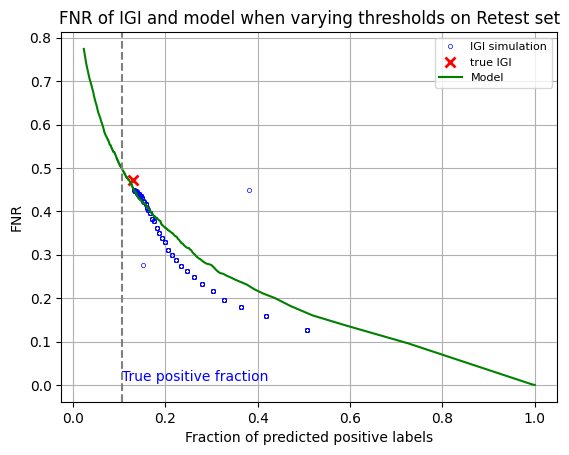

In [62]:

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color='green', label='Model')
plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.001, y = 0.01, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on Retest set')

In [63]:
# plt.style.use('seaborn-v0_8-poster')
# plt.plot(retest_final_thres_df.pos_pred, 
#          retest_final_thres_df.fnr, 
#          '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

# plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr,color='green', label='Model')
# plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
# plt.text(x=true_retest_pos_frac + 0.01, y = 0., s='True positive fraction')
# # plt.xlim(0.3, 0.5)
# # plt.ylim(0.025,0.42)

# plt.xlabel('Fraction of predicted positive labels')
# plt.ylabel('FNR')
# plt.legend(loc='upper right',fontsize=8)
# plt.grid()
# plt.title('FNR of IGI and model when varying thresholds on Retest',family='sans-serif', fontname='Sans',
#           fontsize=14,
#             fontstyle='italic')




Text(0.5, 1.0, 'FPR of IGI and model when varying thresholds on Retest')

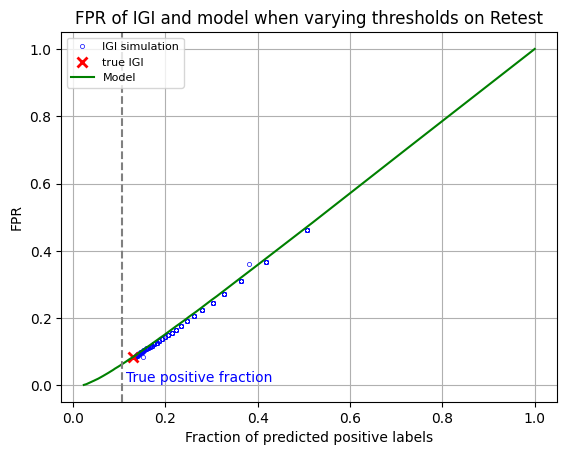

In [64]:

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fpr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(retest_igi_pos_frac, retest_igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fpr, color='green', label='Model')
plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.01, y = 0.01, s='True positive fraction', c='blue')
# plt.xlim(0.3, 0.5)
# plt.ylim(0,0.4)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.title('FPR of IGI and model when varying thresholds on Retest')

In [151]:
retest_final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_retest_final_thres_df.csv', index=False)